# Tidally-locked figures from Nicolas & Vallis (2026): Mechanisms of Superrotation in Slowly-Rotating and Tidally-Locked Planets

Use this notebook to reproduce figures 5-9 from the paper. The notebook requires output from two-level simulations of tidally locked planets.
See README.md for how to run these simulations.

In [1]:
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter1d
import os
import pycwt

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.crs as ccrs

from emfcTools import calc_emfc, calc_emfc_tmean, get_emfc_spectra_nondim_zeta, cospec_kc_from_cospec
from processingTools import open_h5s_wgauge
from plottingTools import plot_map, filter_mode

%load_ext autoreload
%autoreload 2

In [2]:
# Adapt to your local setup
SNAPSHOTS_DIR = '/Users/qnicolas/superrotation/data/' 

# Loading & preparing simulation data

In [3]:
# Parameter grid
tau_rad_nondims = np.array([10,15,25,40,65,100,150,250,400,650,1000])
Ro_Ts  = tau_rad_nondims/100

In [4]:
# # Save simulation output to netcdf, quicker to open
# for Ro_T in Ro_Ts:
#     print(Ro_T)
#     for tau_rad_nondim in tau_rad_nondims:
#         print(tau_rad_nondim)
#         snapshot_id = 'snapshots_2levelnondim_T64_locked_%.2f_%.2f_%i_0p05'%(Ro_T,0.02,tau_rad_nondim)
#         snapshot_id = snapshot_id.replace('.','p')
#         outfile = SNAPSHOTS_DIR + "largesweep_tl/{}.nc".format(snapshot_id)
#         if os.path.isfile(outfile):
#             print(outfile + ' exists')
#         else:
#             snapshot = open_h5s_wgauge(snapshot_id,('s1','s2'),gauge_names=('tau',),SNAPSHOTS_DIR = SNAPSHOTS_DIR + 'largesweep_tl/')
#             snapshot.rename({'':'component'}).to_netcdf(outfile)

In [5]:
# Load simulation data
T64_2lev={}
for Ro_T in Ro_Ts:
    for tau_rad_nondim in tau_rad_nondims:
        snapshot_id = 'snapshots_2levelnondim_T64_locked_%.2f_0p02_%i_0p05'%(Ro_T,tau_rad_nondim)
        snapshot_id = snapshot_id.replace('.','p')
        snapshot = xr.open_dataset(SNAPSHOTS_DIR+"largesweep_tl/%s.nc"%snapshot_id).sel(t=slice(300 * 4 * np.pi,None))
        T64_2lev[Ro_T,tau_rad_nondim] = snapshot

[iacmac-ds4973:39640] shmem: mmap: an error occurred while determining whether or not /var/folders/g5/y1nh4h6x3j3c3lh5frsdkvtc0000gq/T//ompi.iacmac-ds4973.503/jf.0/2994208768/sm_segment.iacmac-ds4973.503.b2780000.0 could be created.


In [6]:
T64_2lev_subset = {key: T64_2lev[key] for key in [(0.1,10), (0.1,400), (10.,10), (10.,250)]}

In [7]:
def prep_sim(sim,Ro_T,phase_speeds = np.linspace(-1.,1.,2001)):
    sim['theta1_tmean'] = sim.theta1.mean('t')
    sim['u1_tmean']     = sim.u1.mean('t')
    sim['u1x_tmean']    = sim['u1_tmean'].mean('longitude')[0]
    sim['u1y_tmean']    = -sim['u1_tmean'].mean('longitude')[1]
    
    calc_emfc(sim,Ro_T)
    sim['mmc'] = sim['mmc'].mean('t')
    sim['emfc'] = sim['emfc'].mean('t')
    calc_emfc_tmean(sim,Ro_T)
    
    cospec = get_emfc_spectra_nondim_zeta(sim,Ro_T)
    sim['cospec'] = cospec
    cospec_transients = cospec * (cospec.frequency !=0)
    cospec_kc = cospec_kc_from_cospec(cospec_transients,phase_speeds = phase_speeds)
    sim['cospec_transients_kc'] = cospec_kc

def smooth(ds,sigma=2):
    return gaussian_filter1d(ds,sigma = sigma) * ds**0 

In [8]:
for key,sim in T64_2lev_subset.items():
    print(key)
    prep_sim(sim,key[0])

(0.1, 10)
(0.1, 400)
(10.0, 10)
(10.0, 250)


In [9]:
# Set plotting attributes
T64_2lev[0.1,10] .attrs['wind_scale'] = 25
T64_2lev[0.1,400].attrs['wind_scale'] = 12.5
T64_2lev[10.,10] .attrs['wind_scale'] = 1.6
T64_2lev[10.,250].attrs['wind_scale'] = 1

T64_2lev[0.1,10] .attrs['levels'] = np.linspace(0.,1.,11)
T64_2lev[0.1,400].attrs['levels'] = np.linspace(0.,1.,11)#np.linspace(0.14,0.54,11)
T64_2lev[10.,10] .attrs['levels'] = np.arange(0.2,0.46,0.025)
T64_2lev[10.,250].attrs['levels'] = np.arange(0.2,0.46,0.025)

T64_2lev[0.1,10] .attrs['ticks'] = T64_2lev[0.1,10] .attrs['levels'][::2]
T64_2lev[0.1,400].attrs['ticks'] = T64_2lev[0.1,400].attrs['levels'][::2]
T64_2lev[10.,10] .attrs['ticks'] = T64_2lev[0.1,400].attrs['levels'][::2]
T64_2lev[10.,250].attrs['ticks'] = None

T64_2lev[0.1,10] .attrs['qk_scale'] = 1
T64_2lev[0.1,400].attrs['qk_scale'] = 0.5
T64_2lev[10.,10] .attrs['qk_scale'] = 0.1
T64_2lev[10.,250].attrs['qk_scale'] = 0.05

T64_2lev[0.1,10] .attrs['cospec_scale'] = 0.021
T64_2lev[0.1,400].attrs['cospec_scale'] = 0.0042
T64_2lev[10.,10] .attrs['cospec_scale'] = 0.84
T64_2lev[10.,250].attrs['cospec_scale'] = 0.168

The following is needed to exactly reproduce Figures 7-8. 
It requires simulations with high-temporal-resolution output of EMFC terms. 

If not available the EMFC plots are simply a bit more noisy.

In [10]:
def calc_emfc_sim_avg(sim, Ro_T):
    tmean = lambda x: (x.isel(t=-1) - x.isel(t=0)) / (sim.t[-1] - sim.t[0])
    prime = lambda x: x - x.mean('longitude')

    sim['mmc'] = tmean(sim['fv1_avg']) + Ro_T * tmean(sim.v1_avg).mean('longitude') * tmean(sim.zeta1_avg).mean('longitude') + Ro_T * tmean(sim.omega_avg).mean('longitude') * tmean(sim.u1mu2_avg).mean('longitude')
    sim['emfc_tmean'] = Ro_T * ( prime(tmean(sim.v1_avg)) * prime(tmean(sim.zeta1_avg)) + prime(tmean(sim.omega_avg)) * prime(tmean(sim.u1mu2_avg)) ).mean('longitude')
    sim['emfc_transients'] = tmean(sim['fv1_avg']+sim['eddy_avg']) - sim['mmc'] - sim['emfc_tmean']
    sim['hyperdiff_tmean'] = tmean(sim['hyperdiff_avg'])


for Ro_T , tau_rad_nondim in [(0.1,10),(0.1,400),(10.,10),(10.,250)]:
    snapshot_id = 'snapshots_2levelnondim_T64_locked_%.2f_0p02_%i_0p05'%(Ro_T,tau_rad_nondim)
    snapshot_id = snapshot_id.replace('.','p')
    if Ro_T == 10. and tau_rad_nondim == 250:
        subdir = 'transition/'
    else:
        subdir = 'largesweep_tl/'
    snapshot_fulloutput = xr.open_dataset(SNAPSHOTS_DIR + subdir + "%s_averages.nc"%snapshot_id)
    for var in ['fv1_avg','eddy_avg','hyperdiff_avg']:
        snapshot_fulloutput[var] = snapshot_fulloutput[var].isel(longitude=0)
    T64_2lev[Ro_T, tau_rad_nondim,"averages"] = snapshot_fulloutput.sel(t=slice(300 * 4 * np.pi,None))

for Ro_T , tau_rad_nondim in [(0.1,10),(0.1,400),(10.,10),(10.,250)]:
    sim = T64_2lev[Ro_T, tau_rad_nondim,"averages"]
    calc_emfc_sim_avg(sim, Ro_T)

# Regime diagram

In [11]:
class Exoplanet():
    def __init__(self,name, Teq,period_ov_earth,mass_over_earth,radius_over_earth):
        self.name = name
        self.Teq = Teq
        self.period = period_ov_earth * 86400
        self.a = radius_over_earth * 6.378e6
        self.g = 9.81 * mass_over_earth / radius_over_earth**2

    def calc_RoT_Trad_1barN2(self):
        ps = 1e5 # 1 bar in Pa
        cp = 1e3 # J/kg/K for N2 atm

        # Lambda = np.sqrt( 8.314 / mu  * self.Teq) / (2*3.14 / self.period * self.a)
        self.Ro_T = cp * self.Teq / (2 * 2 * np.pi / self.period * self.a)**2

        # Taurad:
        taurad = ps * cp / ( self.g * 4 * self.Teq**3 * 5.67e-8) 
        self.tau_rad_nondim = 2 * 2*3.14 / (self.period) * taurad

    def calc_RoT_Trad_1barH2(self):
        ps = 1e5 # Pa  # This is an emission level suggested by Perez-Becker and Showman
        cp = 1.2e4 # J/kg/K for H2 atm

        self.Ro_T = cp * self.Teq / (2 * 2 * np.pi / self.period * self.a)**2

        # Taurad:
        taurad = ps * cp / ( self.g * 4 * self.Teq**3 * 5.67e-8) 
        self.tau_rad_nondim = 2 * 2*3.14 / (self.period) * taurad

In [12]:
# See Appendix D of paper
GJ1132b      = Exoplanet("GJ1132b     ",823 , 1.6  , 1.84, 1.19)
LHS1140_b    = Exoplanet("LHS1140 b   ",311 , 24.7 , 5.6   , 1.7)
Trappist_1b  = Exoplanet("Trappist 1b ",564 , 1.5  , 1.3 , 1.1)
Trappist_1c  = Exoplanet("Trappist 1c ",482 , 2.4  , 1.3 , 1.1)
Trappist_1d  = Exoplanet("Trappist 1d ",406 , 4.0  , 0.4 , 0.78)
f55_Cancri_e = Exoplanet("55 Cancri e ",2700, 0.736, 8., 1.875)
Kepler_10b   = Exoplanet("Kepler 10b  ",3120, 0.837, 3   , 1.47)

for exoplanet in [GJ1132b, LHS1140_b, Trappist_1b, Trappist_1c, Trappist_1d, f55_Cancri_e, Kepler_10b]:
    exoplanet.calc_RoT_Trad_1barN2()
    print(exoplanet.name, "RoT = %.3f"%exoplanet.Ro_T, "Trad = %.2f"%exoplanet.tau_rad_nondim)

GJ1132b      RoT = 1.729 Trad = 5.64
LHS1140 b    RoT = 76.295 Trad = 4.54
Trappist 1b  RoT = 1.219 Trad = 22.60
Trappist 1c  RoT = 2.666 Trad = 22.63
Trappist 1d  RoT = 12.408 Trad = 37.12
55 Cancri e  RoT = 0.483 Trad = 0.20
Kepler 10b   RoT = 1.175 Trad = 0.19


In [13]:
# See Appendix D or paper
HD_189733b = Exoplanet("HD-189733b",1200,2.22,359,12.7) 
HD_209458b = Exoplanet("HD-209458b",1450,3.52,232,15.6) 
HD_149026b = Exoplanet("HD-149026b",1626,2.88,121,8.3)  
HAT_P_7b   = Exoplanet("HAT-P-7b  ",2200,2.20,585,16.9) 
WASP_18b   = Exoplanet("WASP-18b  ",2429,0.94,3636,13.5)
WASP_12b   = Exoplanet("WASP-12b  ",2601,1.09,416,20.4) 

for exoplanet in [HD_189733b,HD_209458b,HD_149026b,HAT_P_7b  ,WASP_18b  ,WASP_12b  ]:
    exoplanet.calc_RoT_Trad_1barH2()
    print(exoplanet.name, "RoT = %.3f"%exoplanet.Ro_T, "Trad = %.2f"%exoplanet.tau_rad_nondim)

HD-189733b RoT = 0.511 Trad = 9.18
HD-209458b RoT = 1.029 Trad = 7.66
HD-149026b RoT = 2.730 Trad = 3.61
HAT-P-7b   RoT = 0.520 Trad = 1.63
WASP-18b   RoT = 0.164 Trad = 0.29
WASP-12b   RoT = 0.104 Trad = 4.09


In [14]:
equilibrated_Us = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
fraction_time_superrotating = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
for i,Ro_T in enumerate(Ro_Ts):
    print(Ro_T)
    for j,tau_rad_nondim in enumerate(tau_rad_nondims):
        print(tau_rad_nondim,end=' ')
        sim = T64_2lev[Ro_T,tau_rad_nondim]

        # Average zonal wind in 2°S-2°N, time average over 300-1000 days
        u_ts = sim.u1[:,0].sel(latitude=slice(-2,2)).mean(('latitude','longitude'))
        equilibrated_Us[i,j] = float(u_ts.mean('t').data)
        fraction_time_superrotating[i,j] = (u_ts>0).mean()

    print('')

equilibrated_Us_xr = xr.DataArray(equilibrated_Us,coords={'Ro_T':np.array(Ro_Ts),'tau_rad_nondim':np.array(tau_rad_nondims)},dims=['Ro_T','tau_rad_nondim'])
unstable = (fraction_time_superrotating > 0.1) * (fraction_time_superrotating < 0.9)
unstable_xr = xr.DataArray(unstable, coords=equilibrated_Us_xr.coords, dims=equilibrated_Us_xr.dims)


0.1
10 15 25 40 65 100 150 250 400 650 1000 
0.15
10 15 25 40 65 100 150 250 400 650 1000 
0.25
10 15 25 40 65 100 150 250 400 650 1000 
0.4
10 15 25 40 65 100 150 250 400 650 1000 
0.65
10 15 25 40 65 100 150 250 400 650 1000 
1.0
10 15 25 40 65 100 150 250 400 650 1000 
1.5
10 15 25 40 65 100 150 250 400 650 1000 
2.5
10 15 25 40 65 100 150 250 400 650 1000 
4.0
10 15 25 40 65 100 150 250 400 650 1000 
6.5
10 15 25 40 65 100 150 250 400 650 1000 
10.0
10 15 25 40 65 100 150 250 400 650 1000 


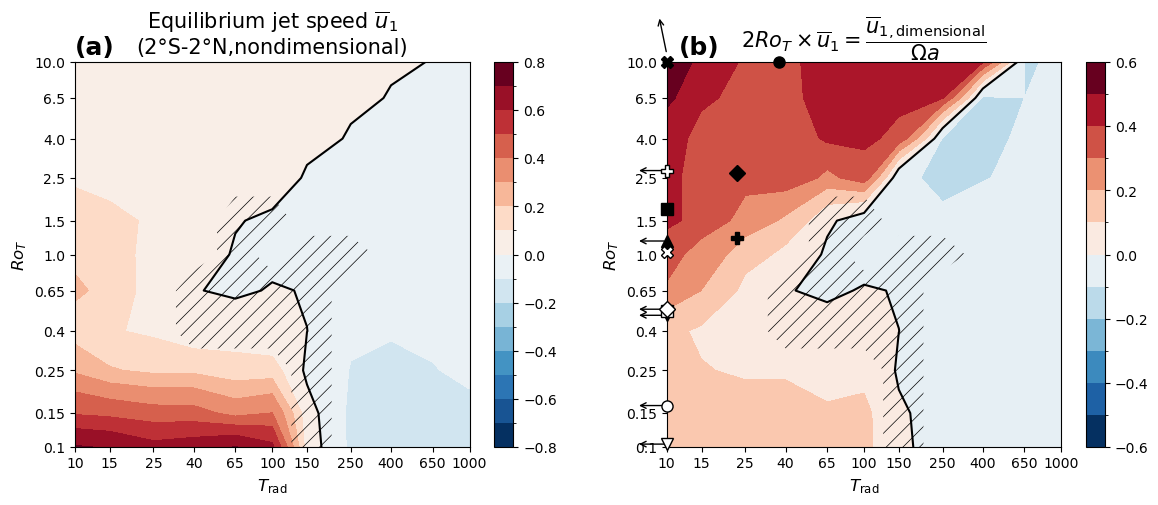

In [15]:
matplotlib.rcParams['hatch.linewidth'] = 0.5
matplotlib.rcParams['font.size'] = 10
fig,axs=plt.subplots(1,2,figsize=(14,5))

# Plot with two nondimensionalizations
for ax,us,levs in zip(axs,
                      [equilibrated_Us_xr, equilibrated_Us_xr * equilibrated_Us_xr.Ro_T * 2],
                      [np.arange(-0.8,0.81,0.1),2*np.arange(-0.3,0.31,0.05)]
                      ):
    us.plot.contourf(ax=ax,levels = levs)
    unstable_xr.plot.contourf(ax=ax, levels=[0.5,1], colors='none', hatches=['','//'], alpha=0,add_colorbar=False)
    us.plot.contour(ax=ax, levels=[0.], colors=['k'])
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_yticks(Ro_Ts)
    ax.set_xticks(tau_rad_nondims)
    ax.set_yticklabels(Ro_Ts)
    ax.set_xticklabels(tau_rad_nondims)
    ax.set_xlabel(r"$T_\mathrm{rad}$",fontsize=12)
    ax.set_ylabel(r"$Ro_T$",fontsize=12)
    ax.minorticks_off()

axs[0].text(0.,1.02,"(a)",fontweight='bold',fontsize=18,transform = axs[0].transAxes)
axs[1].text(0.03,1.02,"(b)",fontweight='bold',fontsize=18,transform = axs[1].transAxes)

# Add exoplanets
markers = ['s','X','P','D','o','v','^']
for i,exoplanet in enumerate([GJ1132b, LHS1140_b, Trappist_1b, Trappist_1c, Trappist_1d, f55_Cancri_e, Kepler_10b]):
    ax.plot(np.clip(exoplanet.tau_rad_nondim,10,1000),np.clip(exoplanet.Ro_T,0.1,10),marker=markers[i],markersize=8,color='k',markerfacecolor='k',zorder=10,clip_on=False)
    if exoplanet.tau_rad_nondim < 5:
        x0 = 10; y0 = exoplanet.Ro_T
        ax.annotate("", xy=(x0,y0), xytext=(x0-3,y0),arrowprops=dict(arrowstyle="<-"),xycoords = 'data',clip_on=False)

colors = plt.cm.plasma(np.linspace(0,1,6))
for i,exoplanet in enumerate([HD_189733b,HD_209458b,HD_149026b,HAT_P_7b  ,WASP_18b  ,WASP_12b  ]):
    ax.plot(np.clip(exoplanet.tau_rad_nondim,10,1000),np.clip(exoplanet.Ro_T,0.1,10),marker=markers[i],markersize=8,color='k',markerfacecolor='w',zorder=10,clip_on=False)
    if exoplanet.tau_rad_nondim < 5:
        x0 = 10; y0 = exoplanet.Ro_T
        ax.annotate("", xy=(x0,y0), xytext=(x0-3,y0),arrowprops=dict(arrowstyle="<-"),xycoords = 'data',clip_on=False)

x0 = 0; y0 = 1.02
ax.annotate("", xy=(x0,y0), xytext=(x0-0.02,y0+0.1),arrowprops=dict(arrowstyle="<-"),xycoords = 'axes fraction',clip_on=False)
    
axs[0].set_title(r"Equilibrium jet speed $\overline{u}_1$"+"\n(2°S-2°N,nondimensional)",fontsize=15)
axs[1].set_title(r"$2Ro_T \times \overline{u}_1 = \dfrac{\overline{u}_{1,\mathrm{dimensional}}}{\Omega a}$",fontsize=15)

fig.savefig('figs/regime_diagram_tl.pdf',format='pdf',bbox_inches='tight')

# Low & high $Ro_T$ figures

In [16]:
def plot_one_sim(sim, axs, Ro_T, tau_rad_nondim, extend_cbar = None):
    try:
        sim_avg = T64_2lev[Ro_T,tau_rad_nondim,"averages"] 
        hyperdiff_desc = r'$\nabla^4$'
    except KeyError:
        print("WARNING: No high-temporal-resolution output for Ro_T = %.1f, tau_rad_nondim = %i"%(Ro_T,tau_rad_nondim), ": EMFC plots will be more noisy")
        sim_avg = sim
        sim_avg['emfc_transients'] = sim_avg['emfc'] - sim_avg['emfc_tmean']
        sim_avg['hyperdiff_tmean'] = -(sim_avg['emfc'] + sim_avg['mmc'])
        hyperdiff_desc = "unresolved transients + "r'$\nabla^4$'

    ###### Plotting the wind and theta fields ######
    ax = axs[0]
    scale = sim.attrs['qk_scale']

    lbl = r'$\mathbf{Ro_T=%.1f, T_{rad}=%i}$'%(Ro_T,tau_rad_nondim)
    c = plot_map(ax,sim.theta1_tmean,sim.u1_tmean, levels = sim.attrs['levels'],extend=extend_cbar,
                wind_disc=3, quiver_kwargs=dict(scale=sim.attrs['wind_scale'],color='w',width=3e-3),
                include_qk=True, qk_scale=scale,qkx = 0.88,qky = 0., add_colorbar=False)
    ax.set_title(lbl,fontweight='bold',fontsize=22)
    ax.set_xlabel('')
    
    ax2 = ax.twiny()
    
    ax2.plot(sim.u1x_tmean,sim.latitude*9.6e4,color='orange',linewidth=3)
    ax2.plot(5*sim.u1y_tmean,sim.latitude*9.6e4,color='orange',linestyle='--',linewidth=3)
    ax2.spines['bottom'].set_visible(True)
    ax2.xaxis.set_ticks_position('bottom')
    ax2.axvline(0.,color='w')
    ax2.spines[['right', 'left','top']].set_visible(False)

    factor = 1.22
    ax2.set_xlim(-factor*scale,factor*scale)
    ax2.set_xticks(np.arange(-.6,.61,.3)*scale)
    ax2.spines.bottom.set_bounds(-0.4*scale, 0.4*scale)
    ax2.tick_params(axis='x', colors='orange')

    ###### Plotting the momentum balance ######
    ax = axs[1]
    sim_avg.mmc             .plot(ax=ax, y='latitude',color='k',linewidth=1.,label = 'MMC')
    sim_avg.emfc_tmean      .plot(ax=ax, y='latitude',color='b',linewidth=2.,label = 'SE')
    sim_avg.emfc_transients .plot(ax=ax, y='latitude',color='g',linestyle='-',linewidth=2,label='TE')    
    (-sim_avg.hyperdiff_tmean).plot(ax=ax, y='latitude',color='darkorange',linestyle=':',linewidth=2,label=hyperdiff_desc)    
    (sim_avg.mmc + sim_avg.emfc_tmean + sim_avg.emfc_transients - sim_avg.hyperdiff_tmean)  .plot(ax=ax,y='latitude',color='darkred',linewidth=.5)

    MM = np.abs(sim.emfc_tmean).max()*1.1
    ax.set_xlim(-MM,MM)
    ax.set_ylim(-90,90)
    ax.grid(alpha=.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks([-45,0,45])
    ax.set_yticklabels(["45°S","0°","45°N"])

    ###### Plotting the cospectrum ######
    ax = axs[2]

    cospec_kc = sim['cospec_transients_kc']
    cospec_kc = cospec_kc.assign_coords(c = cospec_kc.c / Ro_T) * Ro_T

    plot = cospec_kc.sum(('kphi'))   

    MM = sim.attrs['cospec_scale'] 
    dM = sim.attrs['cospec_scale'] / 10.5

    cf = plot.plot.contourf(ax=ax,y='latitude',levels = np.arange(-MM,MM+1e-6,dM),extend='both',add_colorbar=False)
    cbar = plt.colorbar(cf,ax=ax,label='',ticks = np.arange(-MM,MM+1e-6,3*dM))
    cbar.formatter.set_powerlimits((0, 0))
    cbar.formatter.set_useMathText(True)

    (sim.u1x_tmean).plot(ax=ax,y='latitude',color='orange',linewidth=2)

    ax.set_title((Ro_T,tau_rad_nondim))
    ax.set_ylabel('')
    ax.set_yticks(range(-90,91,45))
    ax.set_yticklabels('')#['90°S','45°S','0°','45°N','90°N'])
    ax.set_title('')

    return c

In [17]:
def plot_two_sims(params1, params2, extend_cbar = None):
    matplotlib.rcParams.update({'font.size':18})

    fig = plt.figure(figsize=(20,12))
    map_factor = 2.3
    cbar_factor = 0.5
    gs = gridspec.GridSpec(nrows=4, ncols=5, width_ratios=[(1-cbar_factor)/2 * map_factor,cbar_factor * map_factor,(1-cbar_factor)/2 * map_factor,0.8,1],height_ratios=[1,0.01,1,0.05],hspace=0.2,wspace=0.1, figure=fig)
    axs = np.array([[fig.add_subplot(gs[j,:3], projection = ccrs.Robinson()),
                    fig.add_subplot(gs[j,3]),
                    fig.add_subplot(gs[j,4])
                    ] for j in [0,2]])
    axcbar = fig.add_subplot(gs[3,1])

    for i, (Ro_T, tau_rad_nondim) in enumerate([params1, params2]):
        sim = T64_2lev[Ro_T,tau_rad_nondim]
        c = plot_one_sim(sim, axs[i], Ro_T, tau_rad_nondim, extend_cbar=extend_cbar)

    fig.colorbar(c,cax=axcbar,label=r'$\theta_1$',ticks = sim.attrs['ticks'],orientation='horizontal')

    axs[0,1].legend(loc = (-0.01,1.02), handlelength=1, borderpad=0.2,borderaxespad=0.1,handletextpad=0.2,fontsize=15,labelspacing = 0.2,ncol=4,columnspacing=0.4)

    axs[1,1].set_xlabel(r'MFC (nondim.)')
    axs[1,2].set_xlabel(r'$c$ (nondim.)')
    axs[0,2].set_xlabel('')

    for i,labels in enumerate((["(a)","(b)","(c)"],["(d)","(e)","(f)"])):
        axs[i,0].text(0.06,1.02,labels[0],fontweight='bold',fontsize=25,transform = axs[i,0].transAxes)
        axs[i,1].text(-0.25,1.02,labels[1],fontweight='bold',fontsize=25,transform = axs[i,1].transAxes)
        axs[i,2].text(0.,1.02,labels[2],fontweight='bold',fontsize=25,transform = axs[i,2].transAxes)

    return fig, axs

## Low $Ro_T$

(-0.4, 0.4)

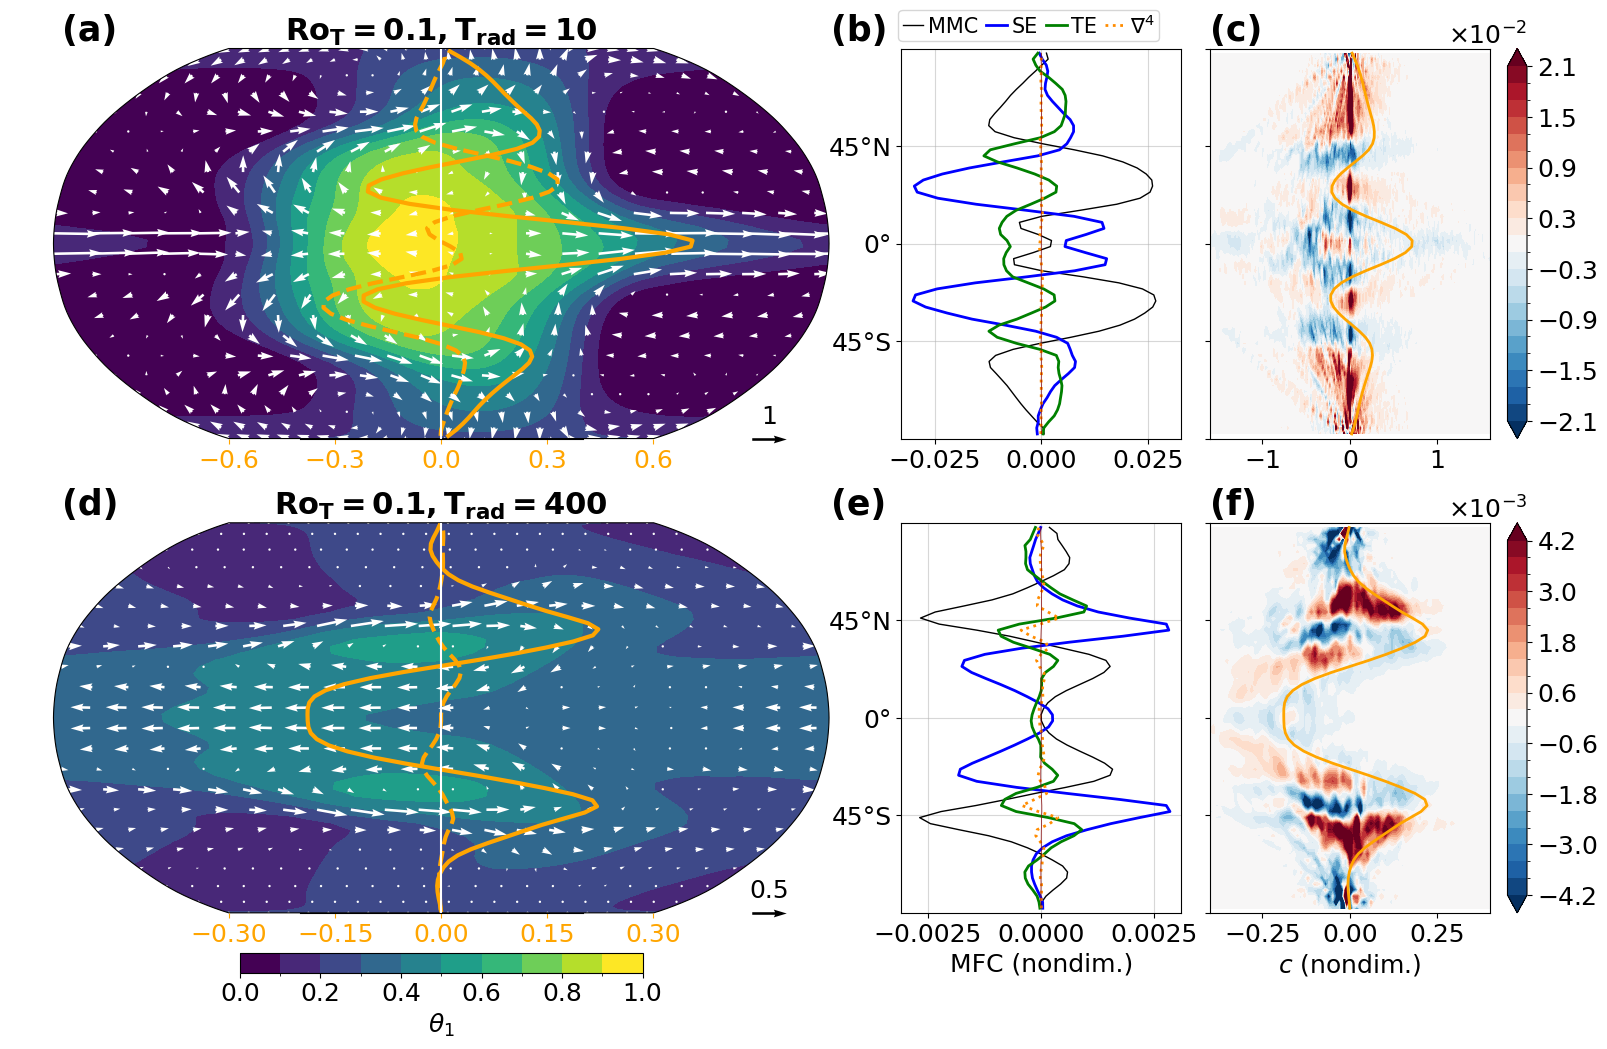

In [18]:
fig, axs =plot_two_sims((0.1,10),(0.1,400))
axs[0,2].set_xlim(-1.6,1.6)
axs[1,2].set_xlim(-0.4,0.4)
# fig.savefig('figs/lowRoT.pdf',format='pdf',bbox_inches='tight')

## High $Ro_T$ 

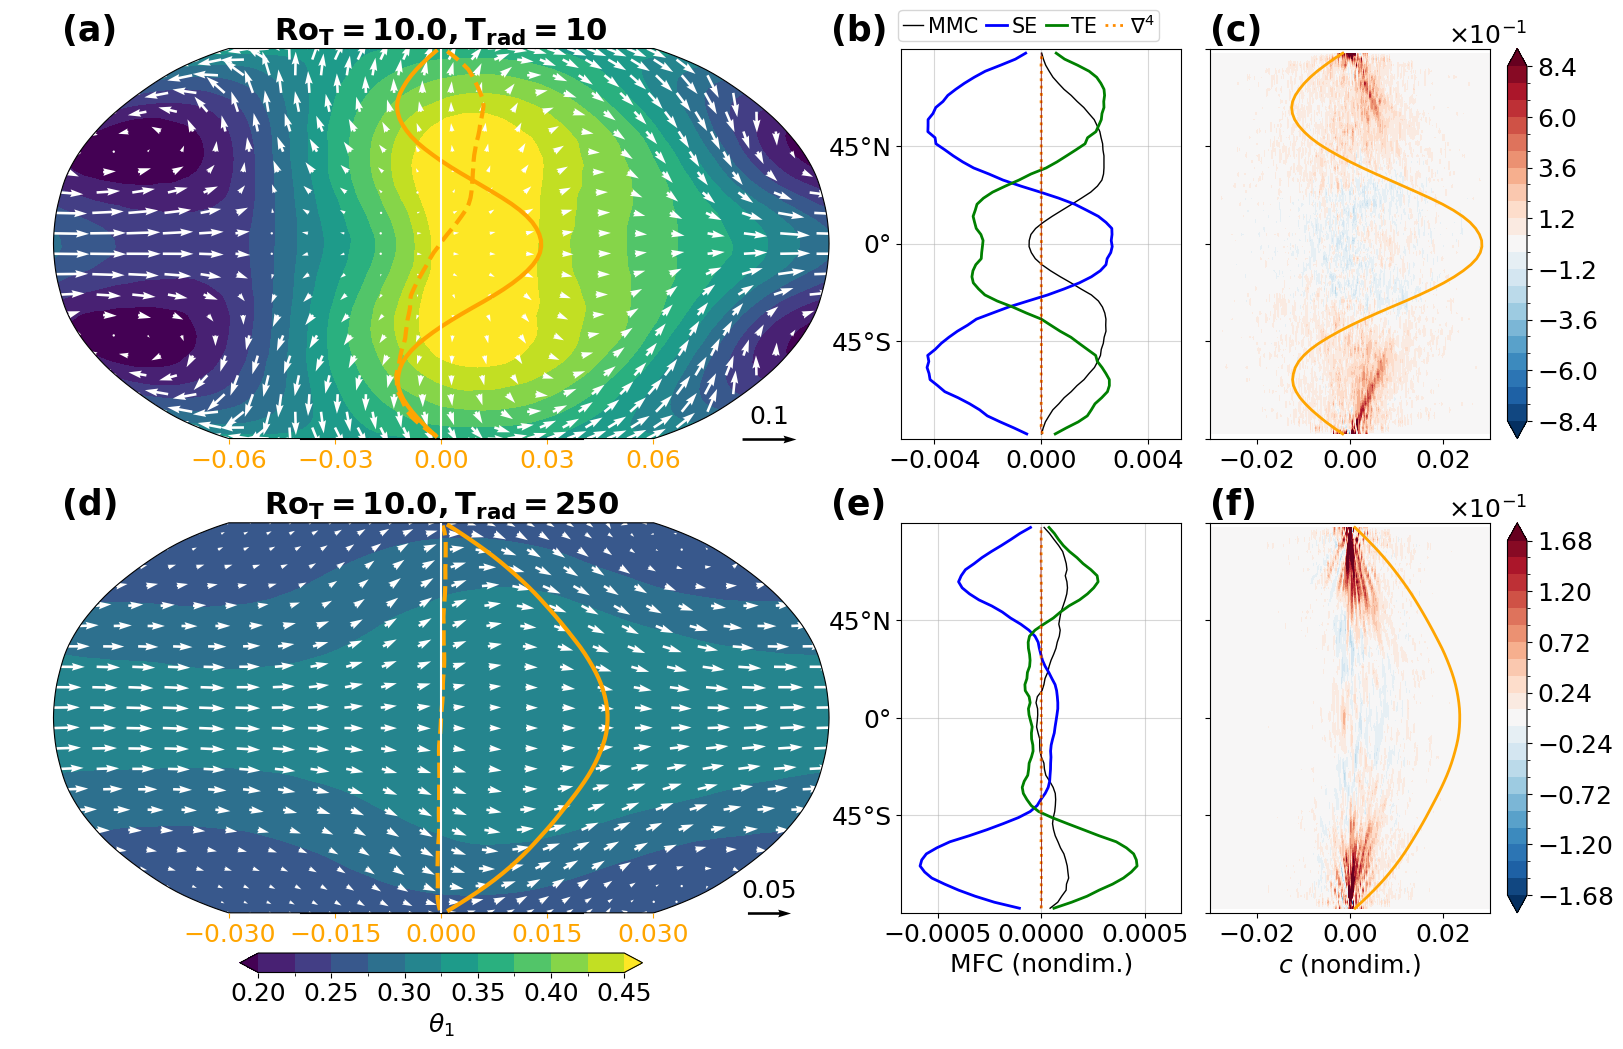

In [19]:
fig, axs = plot_two_sims((10.,10),(10.,250), extend_cbar = 'both')

axs[0,2].set_xlim(-0.03,0.03)
axs[1,2].set_xlim(-0.03,0.03)
axs[0,1].set_xticks([-4e-3,0.,4e-3])

# fig.savefig('figs/highRoT.pdf',format='pdf',bbox_inches='tight')


# RK mode figure

In [20]:
Ro_T, tau_rad_nondim = 10.,250
snapshot_id = 'snapshots_2levelnondim_T64_locked_%.2f_0p02_%i_0p05'%(Ro_T,tau_rad_nondim)
snapshot_id = snapshot_id.replace('.','p')
RK_example = xr.open_dataset(SNAPSHOTS_DIR+"largesweep_tl/%s.nc"%snapshot_id)

In [21]:
# set the limits for scientific notation to always use powers of 10
import matplotlib.ticker                       
cbformat = matplotlib.ticker.ScalarFormatter() 
cbformat.set_powerlimits((0,0))

def plot_mode(ax,sim,k,freq,levs=None,ticks=None,scale=None):
    u = filter_mode( sim.u1[:,0],k,freq).transpose('longitude','latitude')
    minusv = filter_mode(sim.u1[:,1],k,freq).transpose('longitude','latitude')
    u_vector = xr.concat([u,minusv],dim='component')
    phi = filter_mode(sim.Phi1,k,freq)

    plot_map(ax, phi, u_vector,
             levels=levs, cmap = 'RdBu_r', wind_disc=2, 
             quiver_kwargs=dict(scale=scale, color='k'),
             cbar_kwargs = dict(orientation='horizontal',shrink=0.7,pad=0.03,label=r"$\Phi_1$",format=cbformat,ticks=ticks))
    
    ax.set_title(r"$k = %i, \omega = %.3f$"%(k,freq),fontsize=22)

def smooth(ds,sigma=2):
    return gaussian_filter1d(ds,sigma = sigma) * ds**0 
    

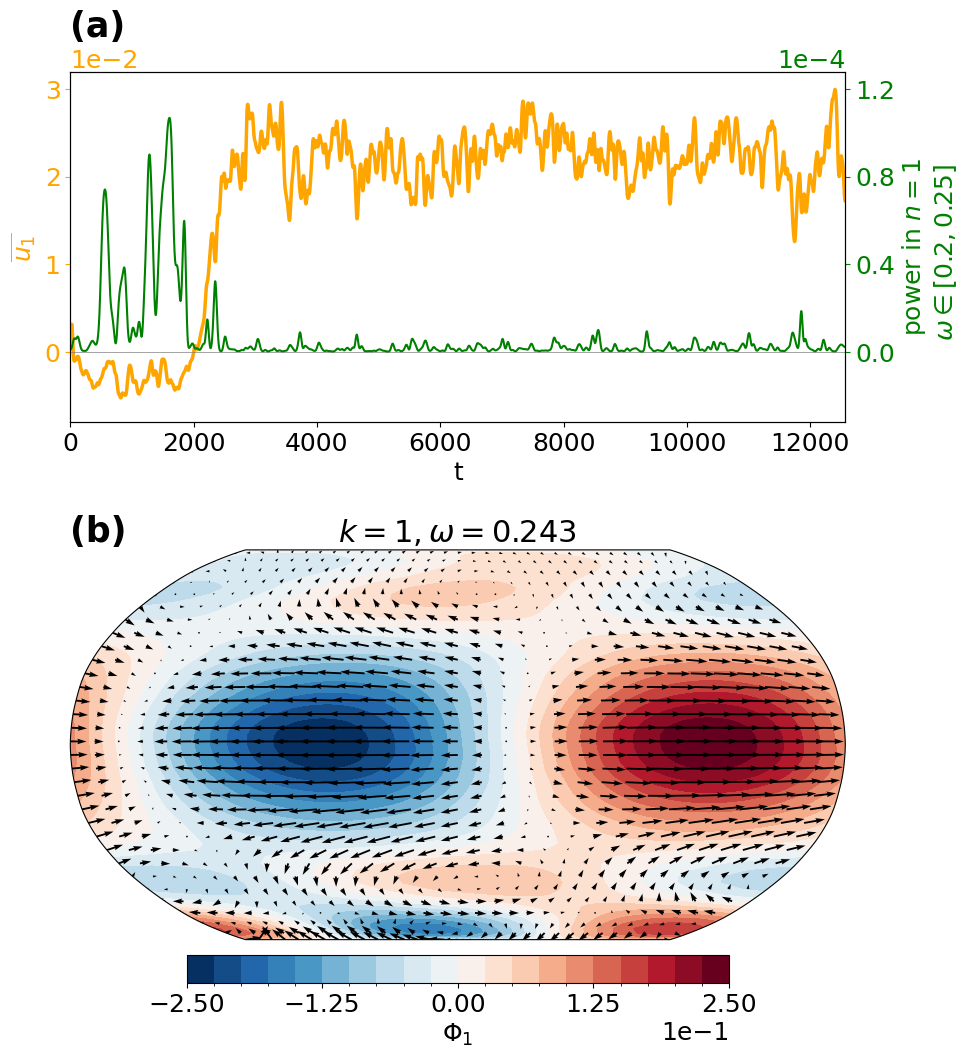

In [22]:
ftz=18
matplotlib.rcParams.update({'font.size':ftz})

fig = plt.figure(figsize=(10,12.5))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios = [1.,1.5], figure=fig)#,hspace=0.4)
ax = fig.add_subplot(gs[0])
ax_wp = ax.twinx() # For wavelet power
ax_map = fig.add_subplot(gs[1], projection=ccrs.Robinson())


######### Timeseries #########
sim = RK_example

# Compute continuous wavelet transform of the n=1 component of the equatorial zonal wind
sim_u1 = sim.u1[:,0].sel(latitude=slice(-30,30)).mean(('latitude'))
sim_u1_k1 = np.fft.rfft(sim_u1,axis=1,norm='forward')[:,1]
wave, scales, freqs, coi, fft, fftfreqs = pycwt.cwt(sim_u1_k1, np.pi)
u1_wavelets_xr = xr.DataArray(wave,dims=(['frequency','t']),coords={'frequency':2*np.pi*freqs, 't':sim.t})

# Average wavelet power in the frequency band [0.2,0.25], and smooth in time with a Gaussian filter (sigma=4 time steps)
u1_wavelet_0p2_pwr = smooth( (np.abs(u1_wavelets_xr)**2).sel(frequency= slice(0.25,0.2)).mean('frequency'), sigma=4)
u1_eq_smooth = smooth( sim_u1.mean('longitude') , sigma=4)

# Plot the smoothed equatorial zonal wind and the wavelet power
u1_wavelet_0p2_pwr.plot(ax=ax_wp,color = 'green')
u1_eq_smooth.plot(ax=ax,color = 'orange',linewidth=2.5)

# Axis cosmetics
ax.set_xlim(0,1000*4*np.pi)
ax.axhline(0.,color='gray',linewidth=0.5)
ax.tick_params(axis='y', colors='orange')
ax_wp.tick_params(axis='y', colors='g')
ax.set_ylabel(r"$\overline{u_1}$",color='orange')
ax_wp.set_ylabel(r"power in $n=1$" + '\n' + r"$\omega\in[0.2,0.25]$  ",color='green')

####### Map of mode structure #######
sim = sim.sel(t=slice(0,2000))

# Get cospectrum of eddy momentum flux convergence over spinup period (see Appendix E of paper)
# The goal is to find the frequency that contributes the most to equatorial jet acceleration during spinup
cospec = get_emfc_spectra_nondim_zeta(sim,Ro_T)
cospec_eq_RKband = cospec.sel(latitude=slice(-10,10),kphi=1).mean('latitude') * (cospec.frequency>=0.2) * (cospec.frequency<=0.25)
freq = cospec.frequency[cospec_eq_RKband.argmax()] # This is the frequency that contributes the most to equatorial jet acceleration during spinup

# Plot the structure of the mode with wavenumber k=1 and the frequency found above
levs = np.arange(-2.5,2.51,0.25)*1e-1 
ticks = levs[::5]
plot_mode(ax_map,sim,1,freq,levs = levs,ticks=ticks)

# Axis cosmetics
ax_range = np.array([-0.008,0.032])
for ax, range_ in zip([ax,ax_wp],[ax_range,ax_range*4e-3]):
    ax.set_ylim(*range_)
    ax.set_yticks(np.linspace(0,range_[-1]*3/3.2,4))
    ax.ticklabel_format(axis='y', style='sci',scilimits=(0,0))

ax.text(0.,1.1,"(a)",fontweight='bold',fontsize=25,transform = ax.transAxes)
ax_map.text(0.,1.02,"(b)",fontweight='bold',fontsize=25,transform = ax_map.transAxes)

fig.savefig('figs/RK_tidally_locked.pdf',format='pdf',bbox_inches='tight')


# Peturbed drag figure

In [23]:
T64_2lev_pertdrag={}
Ro_Ts = [0.1,1,10]
tau_rad_nondim = 40
Es = [0.,0.02,0.2]

for Ro_T in Ro_Ts:
    for E in Es:
        snapshot_id = 'snapshots_2levelnondim_T64_locked_%.2f_%.2f_%i_0p05'%(Ro_T,E,tau_rad_nondim)
        snapshot_id = snapshot_id.replace('.','p')
        try:
            snapshot = xr.open_dataset(SNAPSHOTS_DIR+"largesweep_tl/%s.nc"%snapshot_id)
        except FileNotFoundError:
            snapshot = xr.open_dataset(SNAPSHOTS_DIR+"pert_drag_tl/%s.nc"%snapshot_id)
        snapshot = snapshot.sel(t=slice(300 * 4 * np.pi, None))
        snapshot['theta1_tmean'] = snapshot.theta1.mean('t')
        snapshot['u1_tmean']     = snapshot.u1.mean('t')
        T64_2lev_pertdrag[Ro_T,E] = snapshot

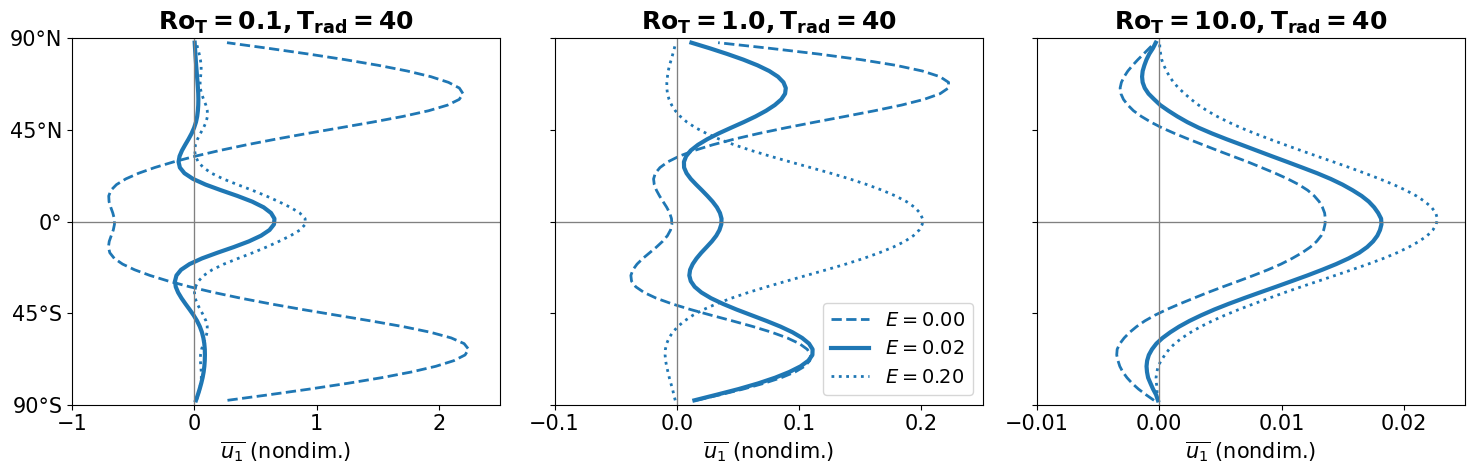

In [24]:
matplotlib.rcParams.update({'font.size':15})

fig,axs = plt.subplots(1,3,figsize=(15,5))
for i,Ro_T in enumerate(Ro_Ts):
    ax=axs[i]
    for j,E in enumerate(Es):
        sim = T64_2lev_pertdrag[Ro_T,E]
        u_mean = sim.u1[:,0].mean(('longitude', 't'))
        u_mean.plot(ax=ax,color='C0',linestyle = ['--','-',':'][j],linewidth=[2,3,2][j],y='latitude',label=r"$E=%.2f$"%(E))

        # Axis cosmetics
        ax.set_ylim(-90,90)
        ax.axhline(0.,color='gray',linewidth=.8)
        ax.axvline(0.,color='gray',linewidth=.8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_yticks(range(-90,91,45))

        if i==0:
            ax.set_yticklabels(["90°S","45°S","0°","45°N","90°N"])
        else:
            ax.set_yticklabels('')

        lbl = r'$\mathbf{Ro_T=%.1f, T_{rad}=%i}$'%(Ro_T,tau_rad_nondim)
        ax.set_title(lbl,fontweight='bold',fontsize=18)
        ax.set_xlabel(r"$\overline{u_1}$ (nondim.)",color='k')
        ax.set_xlim(*np.array([-1.,2.5])/10**i)
        ax.set_xticks(np.arange(-1.,2.5,1.)/10**i)

axs[1].legend(fontsize=14)
fig.tight_layout()
# fig.savefig('figs/dragvnodrag.pdf',format='pdf',bbox_inches='tight')
